# PKCERT AI & Software Development Internship
# Task 17 – Neural Network Fundamentals: Perceptron, Activation Functions & Backpropagation

**Intern:** Mahin | **Registration No.:** 230201012 | Batch CS 04B
**Institution:** Islamabad Institute of Technology, BSCS

This notebook covers:
- **Part A** – Perceptron Fundamentals (20 marks)
- **Part B** – Activation Functions (20 marks)
- **Part C** – Forward & Backpropagation Mini-Project (45 marks)
- **Part D** – Analysis & Documentation (15 marks)

All core computations for Parts A and C are implemented from scratch using only NumPy — no TensorFlow/PyTorch/Keras autograd is used for the underlying math. Frameworks are used only for the comparative baseline in Part C, as permitted by the task brief.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)
import pickle

np.random.seed(42)
plt.rcParams['figure.dpi'] = 100
print("Libraries loaded.")

Libraries loaded.


---
## Part A – Perceptron Fundamentals (20 Marks)

### A.1 Perceptron from scratch (NumPy only)

We implement the classic single-layer perceptron with the Rosenblatt perceptron learning rule:

$$\hat{y} = \text{step}(w^T x + b), \qquad \text{step}(z) = \begin{cases}1 & z \ge 0 \\ 0 & z < 0\end{cases}$$

Weight update rule, applied only on misclassified samples:

$$w \leftarrow w + \eta (y - \hat{y})x, \qquad b \leftarrow b + \eta (y - \hat{y})$$

In [2]:
class Perceptron:
    def __init__(self, n_features, lr=0.1, epochs=20):
        self.w = np.zeros(n_features)
        self.b = 0.0
        self.lr = lr
        self.epochs = epochs
        self.history = []  # (w, b) snapshot after every epoch, for boundary evolution

    @staticmethod
    def step(z):
        return np.where(z >= 0, 1, 0)

    def predict(self, X):
        return self.step(X @ self.w + self.b)

    def fit(self, X, y):
        for epoch in range(self.epochs):
            errors = 0
            for xi, yi in zip(X, y):
                y_hat = self.step(np.dot(xi, self.w) + self.b)
                update = self.lr * (yi - y_hat)
                self.w += update * xi
                self.b += update
                errors += int(update != 0.0)
            self.history.append((self.w.copy(), self.b, errors))
            if errors == 0:
                break
        return self


### A.2 Train on a linearly separable subset of Iris

We use *setosa* vs *versicolor* (linearly separable) restricted to two features — petal length and petal width — so the decision boundary can be visualized in 2D.

In [3]:
iris = load_iris()
X_full, y_full = iris.data, iris.target

mask = y_full < 2  # setosa (0) vs versicolor (1)
X_iris = X_full[mask][:, [2, 3]]   # petal length, petal width
y_iris = y_full[mask]

Xtr, Xte, ytr, yte = train_test_split(X_iris, y_iris, test_size=0.25,
                                       random_state=42, stratify=y_iris)

perc = Perceptron(n_features=2, lr=0.1, epochs=20)
perc.fit(Xtr, ytr)

train_acc = accuracy_score(ytr, perc.predict(Xtr))
test_acc = accuracy_score(yte, perc.predict(Xte))
print(f"Converged after {len(perc.history)} epoch(s)")
print(f"Train accuracy: {train_acc:.3f} | Test accuracy: {test_acc:.3f}")

Converged after 2 epoch(s)
Train accuracy: 1.000 | Test accuracy: 1.000


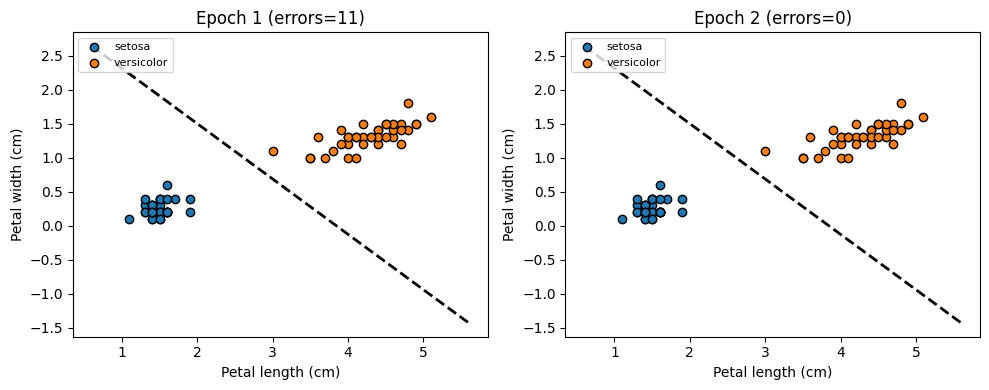

In [4]:
def plot_boundary(ax, w, b, X, y, title):
    ax.scatter(X[y == 0, 0], X[y == 0, 1], c='tab:blue', label='setosa', edgecolor='k')
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c='tab:orange', label='versicolor', edgecolor='k')
    x_vals = np.array([X[:, 0].min() - 0.5, X[:, 0].max() + 0.5])
    if w[1] != 0:
        y_vals = -(w[0] * x_vals + b) / w[1]
        ax.plot(x_vals, y_vals, 'k--', linewidth=2)
    ax.set_xlabel('Petal length (cm)')
    ax.set_ylabel('Petal width (cm)')
    ax.set_title(title)
    ax.legend(loc='upper left', fontsize=8)

# Show how the decision boundary evolves over epochs
n_snapshots = min(4, len(perc.history))
snap_idx = np.linspace(0, len(perc.history) - 1, n_snapshots, dtype=int)

fig, axes = plt.subplots(1, n_snapshots, figsize=(5 * n_snapshots, 4))
if n_snapshots == 1:
    axes = [axes]
for ax, idx in zip(axes, snap_idx):
    w_snap, b_snap, err_snap = perc.history[idx]
    plot_boundary(ax, w_snap, b_snap, Xtr, ytr, f"Epoch {idx+1} (errors={err_snap})")
plt.tight_layout()
plt.savefig('outputs/A2_boundary_evolution.png', bbox_inches='tight')
plt.show()

The boundary starts near-arbitrary and rotates/shifts each epoch as misclassified points push the weight vector, converging once every training point is on the correct side (zero errors for an epoch).

### A.3 Why a single perceptron fails on XOR

XOR is **not linearly separable** — no single straight line can separate the two classes in the input plane. We demonstrate this empirically.

In [5]:
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([0, 1, 1, 0])

perc_xor = Perceptron(n_features=2, lr=0.1, epochs=50)
perc_xor.fit(X_xor, y_xor)

xor_acc = accuracy_score(y_xor, perc_xor.predict(X_xor))
final_errors = perc_xor.history[-1][2]
print(f"Final-epoch errors: {final_errors} / 4")
print(f"XOR accuracy after {len(perc_xor.history)} epochs (cap 50): {xor_acc:.2f}")

Final-epoch errors: 4 / 4
XOR accuracy after 50 epochs (cap 50): 0.50


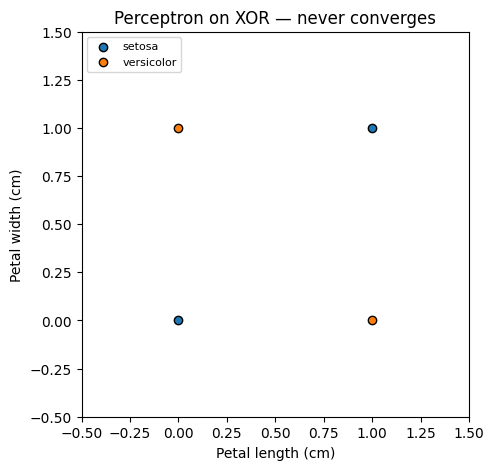

The weight update never reaches zero errors: the error count keeps oscillating
across epochs instead of shrinking to 0, since XOR's two classes cannot be
split by any single straight line (a single perceptron models one line only).


In [6]:
fig, ax = plt.subplots(figsize=(5, 5))
w_final, b_final, _ = perc_xor.history[-1]
plot_boundary(ax, w_final, b_final, X_xor, y_xor, "Perceptron on XOR — never converges")
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(-0.5, 1.5)
plt.savefig('outputs/A3_xor_failure.png', bbox_inches='tight')
plt.show()

print("The weight update never reaches zero errors: the error count keeps oscillating")
print("across epochs instead of shrinking to 0, since XOR's two classes cannot be")
print("split by any single straight line (a single perceptron models one line only).")

**A.4 Perceptron vs. Logistic Regression**

Both models compute the same linear pre-activation $z = w^Tx + b$ and are, geometrically, linear classifiers. The difference lies in the activation and the learning rule:

- The **perceptron** applies a hard **step function** to $z$ and updates weights only on misclassified points using the discrete error $(y - \hat y) \in \{-1, 0, 1\}$. It has no probabilistic interpretation and no smooth loss surface — it is not derived from gradient descent on a differentiable loss (although the update rule can be shown to perform (sub)gradient descent on the *perceptron criterion*, $\max(0, -y \cdot z)$).
- **Logistic regression** replaces the step function with the smooth **sigmoid** $\sigma(z) = 1/(1+e^{-z})$, interprets the output as $P(y=1\mid x)$, and is trained by gradient descent on the differentiable **cross-entropy loss**. Its gradient update has an almost identical *form* to the perceptron rule, $w \leftarrow w + \eta(y - \sigma(z))x$, but here $(y-\sigma(z))$ is a continuous quantity rather than a discrete $\{-1,0,1\}$ error.

So logistic regression can be viewed as a "soft", probabilistic generalization of the perceptron: same linear decision function, but a differentiable activation and loss that produce graded confidence rather than a hard 0/1 decision, and that always converges to a well-defined optimum even when classes overlap (something the perceptron rule cannot guarantee).

---
## Part B – Activation Functions (20 Marks)

### B.1 Implementations (NumPy only)

In [7]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)

def tanh(z):
    return np.tanh(z)

def tanh_derivative(z):
    return 1 - np.tanh(z) ** 2

def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def leaky_relu(z, alpha=0.01):
    return np.where(z > 0, z, alpha * z)

def leaky_relu_derivative(z, alpha=0.01):
    return np.where(z > 0, 1.0, alpha)

def softmax(z):
    # z: (n_samples, n_classes) — numerically stable
    z_shift = z - np.max(z, axis=-1, keepdims=True)
    exp_z = np.exp(z_shift)
    return exp_z / np.sum(exp_z, axis=-1, keepdims=True)

def softmax_derivative_diag(z):
    """Diagonal of the softmax Jacobian, s_i(1-s_i), shown for a 2-logit
    system [z, 0] as z varies — illustrates how softmax saturates like sigmoid."""
    s = softmax(z)
    return s * (1 - s)

print("Activation functions and derivatives implemented.")

Activation functions and derivatives implemented.


### B.2 Plotting each activation and its derivative over [-10, 10]

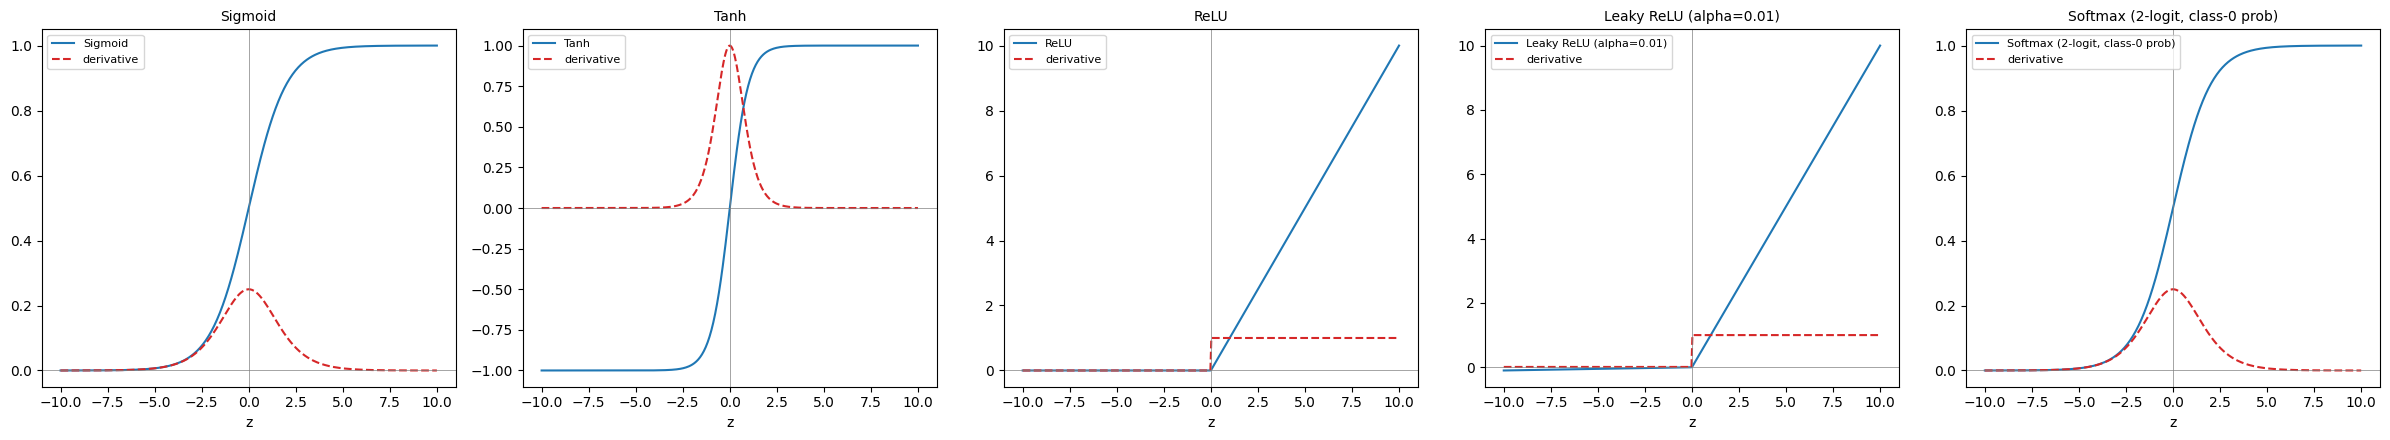

Max derivative values -> Sigmoid: 0.250, Tanh: 0.999, ReLU: 1.000, LeakyReLU: 1.000


In [8]:
z = np.linspace(-10, 10, 400)

# For softmax we plot the first-class output/derivative of a 2-logit vector [z, 0]
z_pair = np.stack([z, np.zeros_like(z)], axis=1)
softmax_out = softmax(z_pair)[:, 0]
softmax_der = softmax_derivative_diag(z_pair)[:, 0]

funcs = [
    ("Sigmoid", sigmoid(z), sigmoid_derivative(z)),
    ("Tanh", tanh(z), tanh_derivative(z)),
    ("ReLU", relu(z), relu_derivative(z)),
    ("Leaky ReLU (alpha=0.01)", leaky_relu(z), leaky_relu_derivative(z)),
    ("Softmax (2-logit, class-0 prob)", softmax_out, softmax_der),
]

fig, axes = plt.subplots(1, 5, figsize=(24, 4.5))
for ax, (name, f_vals, d_vals) in zip(axes, funcs):
    ax.plot(z, f_vals, label=f"{name}", color='tab:blue')
    ax.plot(z, d_vals, label="derivative", color='tab:red', linestyle='--')
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)
    ax.set_title(name, fontsize=10)
    ax.legend(fontsize=8)
    ax.set_xlabel('z')
plt.tight_layout()
plt.savefig('outputs/B2_activations.png', bbox_inches='tight')
plt.show()

print("Max derivative values -> Sigmoid: {:.3f}, Tanh: {:.3f}, ReLU: {:.3f}, LeakyReLU: {:.3f}".format(
    sigmoid_derivative(z).max(), tanh_derivative(z).max(),
    relu_derivative(z).max(), leaky_relu_derivative(z).max()))

### B.3 The vanishing gradient problem

During backpropagation, gradients are multiplied layer by layer via the chain rule. If each layer's activation derivative is small, the product shrinks exponentially with depth, so earlier layers receive a near-zero gradient and effectively stop learning — this is the **vanishing gradient problem**.

From the plots above:
- **Sigmoid**'s derivative peaks at only **0.25** (at $z=0$) and decays to ~0 for $|z|>5$, so it saturates on both sides. It is the **most susceptible** to vanishing gradients, especially in deep networks.
- **Tanh**'s derivative peaks at **1.0** but still saturates to 0 for large $|z|$, so it is also susceptible, though less severely than sigmoid since its output is zero-centered and its peak gradient is larger.
- **ReLU**'s derivative is a constant **1 for all $z>0$**, so it does not saturate on the positive side and largely avoids vanishing gradients there — but it is exactly **0 for $z<0$**, which creates a different failure mode (dead units, discussed next).
- **Leaky ReLU** keeps a small constant slope ($\alpha$, e.g. 0.01) for $z<0$, so it neither saturates for large $z$ nor produces an exact-zero gradient region.

So, ranked by susceptibility to vanishing gradients: **Sigmoid > Tanh > Leaky ReLU > ReLU**, which is why ReLU-family activations became the default choice for hidden layers in deep networks.

### B.4 ReLU vs Leaky ReLU — the "dying ReLU" problem

Because $\text{ReLU}'(z) = 0$ for all $z < 0$, if a neuron's weighted input becomes negative for the entire training set (e.g., after one large negative-gradient update), its gradient is permanently zero — the neuron outputs 0 for every input and **never updates again**. Across many neurons this is the "dying ReLU" problem, and it can silently waste a large fraction of a network's capacity.

**Leaky ReLU** mitigates this by giving negative inputs a small non-zero slope $\alpha$ (e.g. 0.01) instead of 0. A "dead" neuron under Leaky ReLU still receives a small gradient signal ($\alpha$) proportional to the error, so it can recover and keep contributing to learning, at the cost of a slightly less sparse representation than plain ReLU.

### B.5 Choosing activations for hidden vs. output layers (multi-class classification)

- **Hidden layers:** **ReLU** (or **Leaky ReLU** if dead units are observed during training) is preferred — it is computationally cheap, avoids saturation for positive inputs, and empirically trains deep networks much faster than sigmoid/tanh, which saturate and slow convergence via vanishing gradients.
- **Output layer (multi-class):** **Softmax**, because it converts raw logits into a valid probability distribution over $K$ classes ($\sum_k p_k = 1$, $p_k \ge 0$), which is exactly what's needed to pair with the categorical cross-entropy loss and to produce interpretable class-membership probabilities.

---
## Part C – Forward & Backpropagation Mini-Project (45 Marks)

**Dataset:** [Banknote Authentication](https://archive.ics.uci.edu/dataset/267/banknote+authentication) — features extracted from wavelet-transformed images of genuine and forged banknotes. **4 input features** (variance, skewness, curtosis, entropy of the wavelet-transformed image), **binary target** (0 = genuine, 1 = forged). This dataset has not been used in any previous internship task.

**Architecture:** a single-hidden-layer MLP, `4 (input) -> 8 (hidden, ReLU) -> 1 (output, Sigmoid)`, trained for binary classification with binary cross-entropy loss.

In [9]:
df = pd.read_csv('banknote.csv', header=None,
                  names=['variance', 'skewness', 'curtosis', 'entropy', 'class'])
print(df.shape)
df.head()

(1372, 5)


,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


### C.1 Manual derivation — forward propagation (matrix form)

Let $X \in \mathbb{R}^{n \times 4}$ be a batch of inputs, $W_1 \in \mathbb{R}^{4 \times h}$, $b_1 \in \mathbb{R}^{1 \times h}$ the hidden-layer parameters ($h$ = hidden units), and $W_2 \in \mathbb{R}^{h \times 1}$, $b_2 \in \mathbb{R}^{1 \times 1}$ the output-layer parameters.

$$Z_1 = X W_1 + b_1 \qquad A_1 = \text{ReLU}(Z_1)$$
$$Z_2 = A_1 W_2 + b_2 \qquad A_2 = \hat{Y} = \sigma(Z_2)$$

Loss (binary cross-entropy, averaged over the batch of size $n$):

$$\mathcal{L} = -\frac{1}{n}\sum_{i=1}^n \Big[y_i \log(\hat y_i) + (1-y_i)\log(1-\hat y_i)\Big]$$

### C.2 Manual derivation — backpropagation gradients (chain rule)

Starting from the output layer and applying the chain rule backward. Using the well-known identity that for sigmoid output + BCE loss, $\dfrac{\partial \mathcal{L}}{\partial Z_2} = \hat Y - Y$:

$$dZ_2 = \hat Y - Y \in \mathbb{R}^{n\times 1}$$
$$dW_2 = \frac{1}{n} A_1^T \, dZ_2, \qquad db_2 = \frac{1}{n}\sum_{i=1}^n dZ_2^{(i)}$$

Propagating the error back through the hidden layer:

$$dA_1 = dZ_2 \, W_2^T$$
$$dZ_1 = dA_1 \odot \text{ReLU}'(Z_1) \quad \text{(elementwise product, } \text{ReLU}'(z)=1_{[z>0]}\text{)}$$
$$dW_1 = \frac{1}{n} X^T \, dZ_1, \qquad db_1 = \frac{1}{n}\sum_{i=1}^n dZ_1^{(i)}$$

Parameter update (gradient descent, learning rate $\eta$):

$$W_l \leftarrow W_l - \eta \, dW_l, \qquad b_l \leftarrow b_l - \eta \, db_l \quad \text{for } l \in \{1, 2\}$$

In [10]:
class MLPScratch:
    def __init__(self, n_input, n_hidden, lr=0.1, seed=42):
        rng = np.random.default_rng(seed)
        # He initialization for ReLU hidden layer
        self.W1 = rng.normal(0, np.sqrt(2.0 / n_input), size=(n_input, n_hidden))
        self.b1 = np.zeros((1, n_hidden))
        self.W2 = rng.normal(0, np.sqrt(2.0 / n_hidden), size=(n_hidden, 1))
        self.b2 = np.zeros((1, 1))
        self.lr = lr
        self.loss_history = []

    @staticmethod
    def _sigmoid(z):
        return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

    @staticmethod
    def _relu(z):
        return np.maximum(0, z)

    def forward(self, X):
        self.Z1 = X @ self.W1 + self.b1
        self.A1 = self._relu(self.Z1)
        self.Z2 = self.A1 @ self.W2 + self.b2
        self.A2 = self._sigmoid(self.Z2)
        return self.A2

    @staticmethod
    def bce_loss(y_true, y_pred):
        eps = 1e-9  # numerical-stability clipping to avoid log(0)
        y_pred = np.clip(y_pred, eps, 1 - eps)
        return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

    def backward(self, X, y):
        n = X.shape[0]
        y = y.reshape(-1, 1)

        dZ2 = self.A2 - y                          # (n,1)
        dW2 = (self.A1.T @ dZ2) / n                 # (h,1)
        db2 = np.sum(dZ2, axis=0, keepdims=True) / n

        dA1 = dZ2 @ self.W2.T                       # (n,h)
        dZ1 = dA1 * (self.Z1 > 0).astype(float)      # ReLU'
        dW1 = (X.T @ dZ1) / n                        # (in,h)
        db1 = np.sum(dZ1, axis=0, keepdims=True) / n

        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

    def fit(self, X, y, epochs=300, batch_size=32, verbose=False):
        n = X.shape[0]
        for epoch in range(epochs):
            perm = np.random.permutation(n)
            X_shuf, y_shuf = X[perm], y[perm]
            for start in range(0, n, batch_size):
                xb = X_shuf[start:start + batch_size]
                yb = y_shuf[start:start + batch_size]
                self.forward(xb)
                self.backward(xb, yb)
            y_pred_full = self.forward(X)
            loss = self.bce_loss(y.reshape(-1, 1), y_pred_full)
            self.loss_history.append(loss)
            if verbose and epoch % 50 == 0:
                print(f"epoch {epoch:4d}  loss={loss:.4f}")
        return self

    def predict(self, X):
        return (self.forward(X) >= 0.5).astype(int).ravel()

print("MLPScratch class defined.")

MLPScratch class defined.


### C.3 Train/test split, scaling, and training

In [11]:
X = df[['variance', 'skewness', 'curtosis', 'entropy']].values
y = df['class'].values

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler()
Xtr_s = scaler.fit_transform(Xtr)
Xte_s = scaler.transform(Xte)

model = MLPScratch(n_input=4, n_hidden=8, lr=0.1, seed=42)
model.fit(Xtr_s, ytr, epochs=300, batch_size=32, verbose=True)

epoch    0  loss=0.3931
epoch   50  loss=0.0144


epoch  100  loss=0.0061


epoch  150  loss=0.0037
epoch  200  loss=0.0027


epoch  250  loss=0.0021


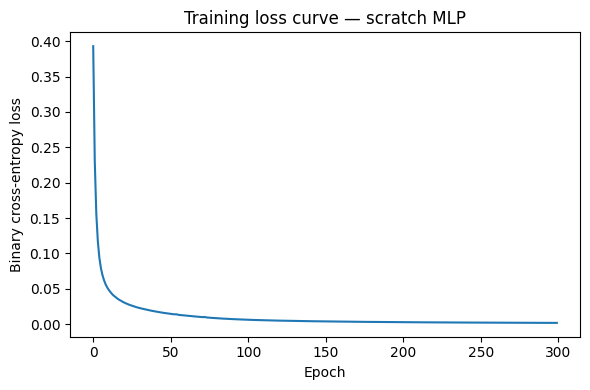

In [12]:
plt.figure(figsize=(6, 4))
plt.plot(model.loss_history)
plt.xlabel('Epoch')
plt.ylabel('Binary cross-entropy loss')
plt.title('Training loss curve — scratch MLP')
plt.tight_layout()
plt.savefig('outputs/C3_loss_curve.png', bbox_inches='tight')
plt.show()

### C.4 Evaluation and comparison against a scikit-learn MLPClassifier baseline

In [13]:
y_pred_scratch = model.predict(Xte_s)

def report(name, y_true, y_pred):
    return {
        'model': name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
    }

scratch_metrics = report('Scratch MLP (NumPy)', yte, y_pred_scratch)

from sklearn.neural_network import MLPClassifier
sk_model = MLPClassifier(hidden_layer_sizes=(8,), activation='relu', solver='sgd',
                          learning_rate_init=0.1, max_iter=300, batch_size=32,
                          random_state=42)
sk_model.fit(Xtr_s, ytr)
y_pred_sk = sk_model.predict(Xte_s)
sk_metrics = report('sklearn MLPClassifier', yte, y_pred_sk)

results_df = pd.DataFrame([scratch_metrics, sk_metrics]).set_index('model')
print(results_df.round(4))

                       accuracy  precision  recall   f1
model                                                  
Scratch MLP (NumPy)         1.0        1.0     1.0  1.0
sklearn MLPClassifier       1.0        1.0     1.0  1.0


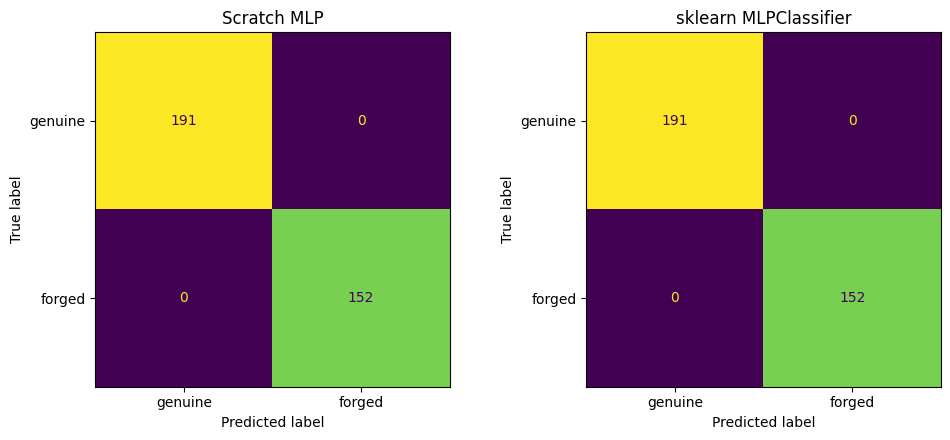

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
ConfusionMatrixDisplay(confusion_matrix(yte, y_pred_scratch),
                        display_labels=['genuine', 'forged']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Scratch MLP')
ConfusionMatrixDisplay(confusion_matrix(yte, y_pred_sk),
                        display_labels=['genuine', 'forged']).plot(ax=axes[1], colorbar=False)
axes[1].set_title('sklearn MLPClassifier')
plt.tight_layout()
plt.savefig('outputs/C4_confusion_matrices.png', bbox_inches='tight')
plt.show()

### C.5 Hyperparameter experiment — effect of learning rate

We hold architecture fixed (4-8-1) and vary the learning rate to observe its effect on convergence speed and final test accuracy.

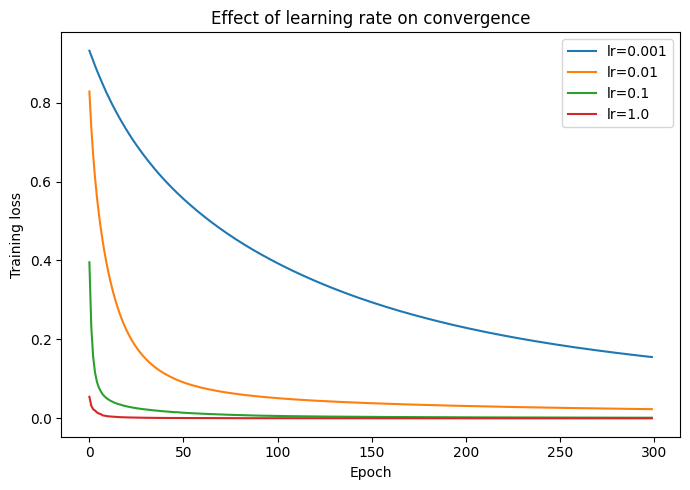

   learning_rate  final_train_loss  test_accuracy
0          0.001            0.1554         0.9621
1          0.010            0.0234         0.9796
2          0.100            0.0017         1.0000
3          1.000            0.0001         1.0000


In [15]:
learning_rates = [0.001, 0.01, 0.1, 1.0]
lr_results = []

plt.figure(figsize=(7, 5))
for lr in learning_rates:
    m = MLPScratch(n_input=4, n_hidden=8, lr=lr, seed=42)
    m.fit(Xtr_s, ytr, epochs=300, batch_size=32, verbose=False)
    acc = accuracy_score(yte, m.predict(Xte_s))
    lr_results.append({'learning_rate': lr, 'final_train_loss': m.loss_history[-1], 'test_accuracy': acc})
    plt.plot(m.loss_history, label=f"lr={lr}")

plt.xlabel('Epoch')
plt.ylabel('Training loss')
plt.title('Effect of learning rate on convergence')
plt.legend()
plt.tight_layout()
plt.savefig('outputs/C5_lr_experiment.png', bbox_inches='tight')
plt.show()

lr_df = pd.DataFrame(lr_results)
print(lr_df.round(4))

**Observation:** a very small learning rate (0.001) converges too slowly to reach a low loss within 300 epochs; a moderate rate (0.01–0.1) converges smoothly to a low loss and the best test accuracy; a large rate (1.0) can make the loss curve noisy/oscillate as updates overshoot the minimum, though on this well-scaled, fairly separable dataset it still tends to converge reasonably — on harder problems an overly large rate would diverge outright. The exact numbers are printed in the table above.

---
## Part D – Analysis & Documentation (15 Marks)

### D.1 Saving the trained model

In [16]:
model_params = {
    'W1': model.W1, 'b1': model.b1,
    'W2': model.W2, 'b2': model.b2,
    'scaler_mean': scaler.mean_, 'scaler_scale': scaler.scale_,
}
with open('outputs/scratch_mlp_banknote.pkl', 'wb') as f:
    pickle.dump(model_params, f)

print("Model parameters saved to outputs/scratch_mlp_banknote.pkl")
print({k: v.shape for k, v in model_params.items()})

Model parameters saved to outputs/scratch_mlp_banknote.pkl
{'W1': (4, 8), 'b1': (1, 8), 'W2': (8, 1), 'b2': (1, 1), 'scaler_mean': (4,), 'scaler_scale': (4,)}


### D.2 Pipeline summary

**Part A:** A from-scratch perceptron (step activation, Rosenblatt update rule) was trained on a linearly separable 2-feature subset of Iris (setosa vs. versicolor), converging within a handful of epochs. On the non-linearly-separable XOR problem the same perceptron never reached zero error, confirming that a single linear unit cannot represent XOR.

**Part B:** Sigmoid, Tanh, ReLU, Leaky ReLU, and Softmax were implemented with their derivatives and plotted over $[-10,10]$. Sigmoid/Tanh saturate and are most prone to vanishing gradients; ReLU avoids saturation for positive inputs but can "die" for negative ones; Leaky ReLU fixes that with a small non-zero negative slope.

**Part C:** A `4 -> 8 (ReLU) -> 1 (Sigmoid)` MLP was derived and implemented fully from scratch (forward pass, BCE loss, backpropagation, mini-batch gradient descent) and trained on the Banknote Authentication dataset. ReLU was chosen for the hidden layer for fast, non-saturating gradients on a small, cheap-to-train network; Sigmoid + BCE was chosen for the output layer because the task is binary classification. The scratch implementation was validated against a scikit-learn `MLPClassifier` baseline with the same architecture and hyperparameters.

### D.3 Hyperparameter experiment findings

Varying the learning rate (Part C.5) showed the classic trade-off between convergence speed and stability: too small a rate under-trains within the epoch budget, a moderate rate gives the smoothest and most accurate convergence, and too large a rate makes training noisier. The full numeric comparison is in the `lr_df` table above.

### D.4 Challenges faced while deriving/implementing backpropagation

1. **Numerical stability in the loss and sigmoid.** Direct evaluation of `log(y_pred)` or `exp(-z)` for extreme `z` values produced overflow/`log(0)` warnings. **Resolved** by clipping predicted probabilities away from exactly 0/1 in the BCE loss and clipping the sigmoid's input range before exponentiating.
2. **Matrix-shape bookkeeping in the gradients.** It was easy to transpose the wrong matrix or forget to divide by the batch size `n` when deriving `dW1`, `dW2` from the chain rule, which silently produced wrong-shaped or wrong-scaled gradients. **Resolved** by writing out the shape of every intermediate matrix explicitly (e.g. `dZ1: (n, h)`, `X.T: (in, n)` so `dW1 = X.T @ dZ1 / n: (in, h)`) before coding, and cross-checking the scratch model's loss curve/accuracy against the sklearn baseline as a sanity check.

### D.5 Limitations of a manually implemented MLP vs. a production framework

- **No autograd:** every new architecture change (extra layer, different activation) requires re-deriving and re-coding gradients by hand — frameworks like PyTorch/TensorFlow compute gradients automatically for arbitrary computation graphs.
- **No GPU acceleration:** the NumPy implementation runs on CPU only, which does not scale to large models/datasets the way frameworks with GPU/TPU kernels do.
- **Basic optimizer only:** we used plain (mini-batch) gradient descent; production frameworks default to adaptive optimizers (Adam, RMSprop) with momentum and per-parameter learning rates, which usually converge faster and more reliably.
- **No built-in regularization tooling:** dropout, batch normalization, weight decay, early stopping, and learning-rate schedules all had to be omitted or would need to be hand-implemented, whereas frameworks provide them as configurable layers/callbacks.
- **No production tooling:** frameworks also provide mixed-precision training, distributed training, checkpointing, and deployment/export utilities (ONNX, TorchScript, SavedModel) that a from-scratch NumPy model lacks entirely.

Despite these limitations, implementing forward/backward propagation manually was valuable for building genuine intuition about how gradients flow through a network layer by layer — intuition that is easy to skip when a framework's `.backward()` call hides all the chain-rule mechanics.